# Solute Transport Toy with mPCN (Shared Draws)

Run a fixed-d example with shared-draws data, then sweep multiple dimensions using shared draws.

In [ ]:
import os
import time
import json
import csv
import hashlib
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

def _resolve_repo_root():
    env_root = os.environ.get("MULTIPROPOSAL_RUN_ROOT")
    if env_root:
        return Path(env_root).expanduser().resolve()
    root = Path.cwd().resolve()
    while root != root.parent and not (root / "pyproject.toml").exists():
        root = root.parent
    return root

repo_root = _resolve_repo_root()

from multiproposal.problems.advection_diffusion import (
    make_omegas_power,
    make_Astar_nn,
    make_Astar_from_atrue,
    params_from_skew,
    prior_diag_from_powerlaw,
    solve_theta,
 )
from multiproposal.problems.advection_diffusion import AdvectionDiffusionToy
from multiproposal.algorithms.mpcn import mpcn_chain
from multiproposal.algorithms.mess import mess_step
from multiproposal.algorithms.effective_sample_size import estimate_effective_sample_size
from multiproposal.utils.run_paths import format_float_tag
from multiproposal.plotting.figure_style import apply_pub_style

In [22]:
# Configuration
seed_data = 0
seed_mcmc = 0
n_iters = 50000
burn_in = 1000
max_lag = 1000
rho = 0.5
P_list = [10]
M_list = [10]
run_mess = True

# Dimension settings
d_fixed = 10
d_list = [10, 20, 30, 40]
d_max = max(d_list)

# Data hyperparameters
kappa = 0.02
sigma = 0.5
alpha = 3.0
gamma = 2.0
tau2 = 2.0
a_mode = 'nearest_neighbor'
use_prior_A = True
shared_draws_seed = seed_data

# Observation configuration
obs_highest_freq = 6
obs_bandwidth = 3
obs_config = 'central_modes'

# Metrics configuration
components_list = [0, 1, 2]  # Set to None to use all components

# Output locations
def _format_list_tag(values):
    return "-".join(str(val).replace(".", "p") for val in values)

def _stable_hash(payload, length=12):
    data = json.dumps(payload, sort_keys=True, separators=(",", ":")).encode("utf-8")
    return hashlib.sha256(data).hexdigest()[:length]

data_id_config = {
    'seed_data': seed_data,
    'seed_mcmc': seed_mcmc,
    'kappa': kappa,
    'sigma': sigma,
    'alpha': alpha,
    'gamma': gamma,
    'tau2': tau2,
    'a_mode': a_mode,
    'use_prior_A': use_prior_A,
    'shared_draws_seed': shared_draws_seed,
    'obs_highest_freq': obs_highest_freq,
    'obs_bandwidth': obs_bandwidth,
    'obs_config': obs_config,
}
data_config = dict(data_id_config)
data_config.update({
    'd_fixed': d_fixed,
    'd_list': d_list,
    'd_max': d_max,
})
algo_config = {
    'n_iters': n_iters,
    'burn_in': burn_in,
    'max_lag': max_lag,
    'rho': rho,
    'P_list': P_list,
    'M_list': M_list,
    'run_mess': run_mess,
    'components_list': components_list,
    'seed_mcmc': seed_mcmc,
}
sweep_config = {
    'd_fixed': d_fixed,
    'd_list': d_list,
}
tag_parts = [
    f"dmax{d_max}",
    f"dlist{_format_list_tag(d_list)}",
    f"P{_format_list_tag(P_list)}",
    f"M{_format_list_tag(M_list)}",
    f"rho{format_float_tag(rho)}",
    f"iters{n_iters}",
    f"seed{seed_mcmc}",
]
data_id = f"data_h{_stable_hash(data_id_config)}"
run_id = f"mpcn_dim_sweep_shared_draws_h{_stable_hash({
    'algorithm': 'mpcn_dim_sweep_shared_draws',
    'algorithm_config': algo_config,
    'sweep': sweep_config,
})}"
estimations_base = repo_root / "estimations" / "solute_transport" / data_id
reports_base = repo_root / "reports" / "solute_transport" / data_id
estimations_fixed_dir = estimations_base / "fixed" / run_id
estimations_sweep_dir = estimations_base / "sweep" / run_id
reports_fixed_dir = reports_base / "fixed" / run_id
reports_sweep_dir = reports_base / "sweep" / run_id
for path in (
    estimations_fixed_dir,
    estimations_sweep_dir,
    reports_fixed_dir,
    reports_sweep_dir,
 ):
    path.mkdir(parents=True, exist_ok=True)
run_config = {
    'dataset': 'solute_transport',
    'algorithm': 'mpcn_dim_sweep_shared_draws',
    'data': data_config,
    'algorithm_config': algo_config,
    'sweep': sweep_config,
}
def _write_run_config(dest_dir):
    config_path = dest_dir / "config.json"
    if not config_path.exists():
        payload = dict(run_config)
        payload['data_id'] = data_id
        payload['run_id'] = run_id
        with open(config_path, 'w', encoding='utf-8') as handle:
            json.dump(payload, handle, indent=2)
_write_run_config(estimations_fixed_dir)
_write_run_config(estimations_sweep_dir)
estimations_dir = estimations_base
reports_dir = reports_sweep_dir
metrics_header = [
    'run_type',
    'sampler',
    'd',
    'P',
    'M',
    'rho',
    'n_iters',
    'burn_in',
    'max_lag',
    'runtime_sec',
    'runtime_min',
    'accept_rate',
    'ess_mean',
    'msjd_mean',
    'ess_per_min',
    'components',
 ]
metrics_rows = []
metrics_csv_path = reports_dir / 'ess_msjd_summary.csv'

if max(d_list) > d_max:
    raise ValueError('d_max must be >= max(d_list)')

print('d_fixed:', d_fixed)
print('d_list:', d_list)
print('P_list:', P_list)
print('M_list:', M_list)
print('run_mess:', run_mess)
print('components_list:', components_list)
print('data_id:', data_id)
print('run_id:', run_id)
print('estimations_fixed_dir:', estimations_fixed_dir)
print('estimations_sweep_dir:', estimations_sweep_dir)
print('reports_sweep_dir:', reports_sweep_dir)

d_fixed: 10
d_list: [10, 20, 30, 40]
P_list: [10]
M_list: [10]
run_mess: True
components_list: [0, 1, 2]
data_id: data_h5d92590a6971
run_id: mpcn_dim_sweep_shared_draws_h65643dc028df
estimations_fixed_dir: /home/senng/multiproposal-internal/estimations/solute_transport/data_h5d92590a6971/fixed/mpcn_dim_sweep_shared_draws_h65643dc028df
estimations_sweep_dir: /home/senng/multiproposal-internal/estimations/solute_transport/data_h5d92590a6971/sweep/mpcn_dim_sweep_shared_draws_h65643dc028df
reports_sweep_dir: /home/senng/multiproposal-internal/reports/solute_transport/data_h5d92590a6971/sweep/mpcn_dim_sweep_shared_draws_h65643dc028df


In [23]:
# Helpers
def compute_msjd_per_param(chain):
    if chain.shape[0] < 2:
        return np.zeros(chain.shape[1])
    jumps = np.diff(chain, axis=0)
    msjd = np.mean(jumps * jumps, axis=0)
    return msjd


def compute_ess_per_param(chain, max_lag):
    if chain.shape[0] < 2:
        return np.zeros(chain.shape[1])
    variances = np.var(chain, axis=0)
    if np.all(variances == 0):
        return np.zeros(chain.shape[1])
    ess_vals = estimate_effective_sample_size(chain, max_lag=max_lag)
    ess_vals = np.asarray(ess_vals, dtype=float)
    ess_vals[variances == 0] = 0.0
    return ess_vals


def _normalize_components(components_in, dim):
    if components_in is None:
        return list(range(dim))
    return [int(c) for c in components_in]


def _split_components(components_idx, dim):
    valid_indices = []
    valid_positions = []
    for pos, idx in enumerate(components_idx):
        if 0 <= idx < dim:
            valid_indices.append(idx)
            valid_positions.append(pos)
    return valid_indices, valid_positions


def _compute_from_chain(chain, components_idx):
    components_count = len(components_idx)
    selected_ess = [np.nan] * components_count
    selected_msjd = [np.nan] * components_count
    if chain is None or chain.size == 0:
        return selected_ess, selected_msjd
    dim = chain.shape[1]
    valid_indices, valid_positions = _split_components(components_idx, dim)
    if not valid_indices:
        return selected_ess, selected_msjd
    chain_sel = chain[:, valid_indices]
    ess_vals = compute_ess_per_param(chain_sel, max_lag=max_lag)
    msjd_vals = compute_msjd_per_param(chain_sel)
    for pos, val in zip(valid_positions, ess_vals):
        selected_ess[pos] = float(val)
    for pos, val in zip(valid_positions, msjd_vals):
        selected_msjd[pos] = float(val)
    return selected_ess, selected_msjd


def _mean_selected(selected):
    arr = np.array(selected, dtype=float)
    if arr.size == 0:
        return np.nan
    if np.all(np.isnan(arr)):
        return np.nan
    return float(np.nanmean(arr))


def summarize_chain_metrics(chain, runtime_sec, label):
    post = chain[burn_in:]
    components_idx = _normalize_components(components_list, post.shape[1])
    selected_ess, selected_msjd = _compute_from_chain(post, components_idx)
    ess_mean = _mean_selected(selected_ess)
    msjd_mean = _mean_selected(selected_msjd)
    runtime_min = runtime_sec / 60.0
    ess_per_min = ess_mean / runtime_min if runtime_min > 0 else np.nan
    print(f"{label} runtime (min): {runtime_min:.2f}")
    print(f"{label} mean ESS (components): {ess_mean:.1f}")
    print(f"{label} mean MSJD (components): {msjd_mean:.4g}")
    print(f"{label} ESS per minute: {ess_per_min:.2f}")
    return {
        "runtime_sec": runtime_sec,
        "runtime_min": runtime_min,
        "components": components_idx,
        "ess_components": selected_ess,
        "msjd_components": selected_msjd,
        "ess_mean": ess_mean,
        "msjd_mean": msjd_mean,
        "ess_per_min": ess_per_min,
    }


def run_mpcn_chain(problem, x0, n_iters, rho, n_props, seed):
    rng = np.random.default_rng(seed)
    t0 = time.perf_counter()
    chain, accepted_index = mpcn_chain(
        x0,
        problem,
        rng,
        n_iters,
        rho=rho,
        n_props=n_props,
        return_indices=True,
    )
    runtime_sec = time.perf_counter() - t0
    accept_rate = float(np.mean(accepted_index != 0))
    return chain, runtime_sec, accept_rate


def run_mess_chain(problem, x0, n_iters, M, seed):
    rng = np.random.default_rng(seed)
    chain = np.zeros((n_iters + 1, problem.dim), dtype=float)
    chain[0] = x0
    x = x0.copy()
    t0 = time.perf_counter()
    for t in range(n_iters):
        x, _, _ = mess_step(
            x,
            problem,
            rng,
            M=M,
            use_lp=False,
            distance_metric="angular",
            lam=0.0,
        )
        chain[t + 1] = x
    runtime_sec = time.perf_counter() - t0
    return chain, runtime_sec


def _format_float_tag(value):
    if value is None:
        return None
    return format_float_tag(value)


def make_chain_path(base_dir, run_type, sampler, d, seed, rho=None, P=None, M=None):
    run_dir = base_dir / run_type / run_id / f"d{d}"
    if sampler == 'mpcn':
        if P is None or rho is None:
            raise ValueError('mpcn requires P and rho')
        stem = f"mpcn_P{P}_rho{_format_float_tag(rho)}_seed{seed}"
    elif sampler == 'mess':
        if M is None:
            raise ValueError('mess requires M')
        stem = f"mess_M{M}_seed{seed}"
    else:
        parts = [sampler]
        if P is not None:
            parts.append(f"P{P}")
        if M is not None:
            parts.append(f"M{M}")
        if rho is not None:
            parts.append(f"rho{_format_float_tag(rho)}")
        parts.append(f"seed{seed}")
        stem = "_".join(parts)
    return run_dir / f"{stem}.npz"


def metrics_json_path(chain_path):
    return chain_path.with_name(chain_path.stem + "_metrics.json")


def save_chain_npz(save_path, chain, metadata):
    save_path.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(save_path, chain=chain, metadata=metadata)


def save_metrics_json(metrics_path, metrics, accept_rate=None, runtime_sec=None):
    payload = dict(metrics)
    if accept_rate is not None:
        payload['accept_rate'] = float(accept_rate)
    if runtime_sec is not None:
        payload['runtime_sec'] = float(runtime_sec)
    metrics_path.parent.mkdir(parents=True, exist_ok=True)
    with open(metrics_path, 'w', encoding='utf-8') as handle:
        json.dump(payload, handle, indent=2)


def load_metrics_json(metrics_path):
    if not metrics_path.exists():
        return None
    with open(metrics_path, 'r', encoding='utf-8') as handle:
        return json.load(handle)


def _load_chain(path):
    if not path.exists():
        return None, {}
    data = np.load(path, allow_pickle=True)
    chain = data['chain']
    metadata = {}
    if 'metadata' in data:
        metadata_raw = data['metadata']
        if isinstance(metadata_raw, np.ndarray) and metadata_raw.shape == ():
            metadata = metadata_raw.item()
        elif isinstance(metadata_raw, dict):
            metadata = metadata_raw
    return chain, metadata


def build_metrics_row(run_type, sampler, d, P, M, rho, metrics, accept_rate=None):
    accept_val = np.nan if accept_rate is None else float(accept_rate)
    return [
        run_type,
        sampler,
        int(d),
        "" if P is None else int(P),
        "" if M is None else int(M),
        "" if rho is None else float(rho),
        int(n_iters),
        int(burn_in),
        int(max_lag),
        float(metrics["runtime_sec"]),
        float(metrics["runtime_min"]),
        accept_val,
        float(metrics["ess_mean"]) if metrics["ess_mean"] is not None else np.nan,
        float(metrics["msjd_mean"]) if metrics["msjd_mean"] is not None else np.nan,
        float(metrics["ess_per_min"]) if metrics["ess_per_min"] is not None else np.nan,
        json.dumps(metrics["components"]),
    ]


def write_metrics_csv(path, rows, header, overwrite=False):
    path.parent.mkdir(parents=True, exist_ok=True)
    write_header = overwrite or not path.exists()
    mode = "w" if overwrite or not path.exists() else "a"
    with open(path, mode, newline="") as handle:
        writer = csv.writer(handle)
        if write_header:
            writer.writerow(header)
        writer.writerows(rows)

In [24]:
# Shared-draws helpers
datasets_by_dim = {}

def get_obs_indices(dim_value, highest_freq, bandwidth):
    highest_freq = min(highest_freq, dim_value)
    bandwidth = min(bandwidth, dim_value)
    start = max(0, highest_freq - bandwidth + 1)
    return np.arange(start, highest_freq + 1, dtype=int)

def get_param_indices_for_dim(dim, shared_draws):
    cache = shared_draws.setdefault('param_indices_cache', {})
    if dim not in cache:
        iju = shared_draws['param_iju']
        mask = (iju[0] < dim) & (iju[1] < dim)
        cache[dim] = np.nonzero(mask)[0]
    return cache[dim]

def build_shared_draws(
    d_max,
    kappa,
    sigma,
    alpha,
    gamma,
    tau2,
    offset,
    a_mode,
    seed,
):
    rng = np.random.default_rng(seed)
    m_max = d_max * (d_max - 1) // 2
    prior_diag_max = prior_diag_from_powerlaw(
        d_max, alpha=alpha, gamma=gamma, tau2=tau2, offset=offset
    )
    if prior_diag_max.shape != (m_max,):
        raise ValueError(f'prior_diag_max must have shape ({m_max},), got {prior_diag_max.shape}')
    if a_mode == 'nearest_neighbor':
        omegas = make_omegas_power(d_max, beta=alpha, c=2.0 ** (-gamma), offset=offset)
        A_true_max = make_Astar_nn(d_max, omegas)
        a_true_max = params_from_skew(A_true_max)
    elif a_mode == 'prior':
        z_prior = rng.standard_normal(m_max)
        a_true_max = z_prior * np.sqrt(prior_diag_max)
        A_true_max = make_Astar_from_atrue(d_max, a_true_max)
    else:
        raise ValueError("a_mode must be 'nearest_neighbor' or 'prior'")
    g_max = np.zeros(d_max, dtype=float)
    g_max[0] = 1.0
    theta_true_max = solve_theta(d_max, a_true_max, g_max, kappa)
    noise_max = rng.standard_normal(d_max)
    z_init = rng.standard_normal(m_max)
    a_init_max = z_init * np.sqrt(prior_diag_max)
    return {
        'd_max': d_max,
        'm_max': m_max,
        'kappa': kappa,
        'sigma': sigma,
        'alpha': alpha,
        'gamma': gamma,
        'tau2': tau2,
        'offset': offset,
        'a_mode': a_mode,
        'param_iju': np.triu_indices(d_max, k=1),
        'param_indices_cache': {},
        'prior_diag': prior_diag_max,
        'a_true': a_true_max,
        'A_true': A_true_max,
        'g': g_max,
        'theta_true': theta_true_max,
        'noise': noise_max,
        'a_init': a_init_max,
    }

def generate_advection_diffusion_data_shared(dim, obs_indices, shared_draws):
    a_mode_local = shared_draws['a_mode']
    param_idx = get_param_indices_for_dim(dim, shared_draws)
    prior_diag = shared_draws['prior_diag'][param_idx]
    g = shared_draws['g'][:dim]
    if a_mode_local == 'nearest_neighbor':
        omegas = make_omegas_power(
            dim,
            beta=shared_draws['alpha'],
            c=2.0 ** (-shared_draws['gamma']),
            offset=shared_draws['offset'],
        )
        A_true = make_Astar_nn(dim, omegas)
        a_true = params_from_skew(A_true)
        theta_true = solve_theta(dim, a_true, g, shared_draws['kappa'])
    elif a_mode_local == 'prior':
        a_true = shared_draws['a_true'][param_idx]
        A_true = make_Astar_from_atrue(dim, a_true)
        theta_true = shared_draws['theta_true'][:dim]
    else:
        raise ValueError("a_mode must be 'nearest_neighbor' or 'prior'")
    noise = shared_draws['noise'][:dim]
    y = theta_true[obs_indices] + shared_draws['sigma'] * noise[obs_indices]
    a_init = shared_draws['a_init'][param_idx]
    return {
        'dim': dim,
        'kappa': shared_draws['kappa'],
        'alpha': shared_draws['alpha'],
        'gamma': shared_draws['gamma'],
        'tau2': shared_draws['tau2'],
        'sigma': shared_draws['sigma'],
        'obs_indices': obs_indices,
        'prior_diag': prior_diag,
        'a_true': a_true,
        'A_true': A_true,
        'g': g,
        'theta_true': theta_true,
        'y': y,
        'a_init': a_init,
    }

def get_dataset_for_dim(d):
    if d in datasets_by_dim:
        return datasets_by_dim[d]
    obs_indices = get_obs_indices(d, obs_highest_freq, obs_bandwidth)
    data = generate_advection_diffusion_data_shared(d, obs_indices, shared_draws)
    data['obs_indices'] = obs_indices
    datasets_by_dim[d] = data
    return data

def build_problem_for_dim(d):
    data = get_dataset_for_dim(d)
    obs_indices = data['obs_indices']
    problem = AdvectionDiffusionToy(
        dim=d,
        kappa=kappa,
        sigma=sigma,
        y=data['y'],
        obs_indices=obs_indices,
        g=data['g'],
        prior_diag=data['prior_diag'],
    )
    return problem, data['a_init'], data

In [25]:
shared_draws = build_shared_draws(
    d_max=d_max,
    kappa=kappa,
    sigma=sigma,
    alpha=alpha,
    gamma=gamma,
    tau2=tau2,
    offset=1.0,
    a_mode='prior' if use_prior_A else a_mode,
    seed=shared_draws_seed,
)
print('Shared draws ready with d_max:', shared_draws['d_max'])

Shared draws ready with d_max: 40


In [26]:
# Fixed-d example
problem_fixed, a_init_fixed, data_fixed = build_problem_for_dim(d_fixed)
x0_fixed = a_init_fixed.copy()

fixed_results = {'mpcn': {}, 'mess': {}}

for P in P_list:
    save_path = make_chain_path(
        estimations_dir,
        'fixed',
        'mpcn',
        d_fixed,
        seed_mcmc,
        rho=rho,
        P=P,
    )
    metrics_path = metrics_json_path(save_path)
    if save_path.exists():
        chain, metadata = _load_chain(save_path)
        runtime_sec = float(metadata.get('runtime_sec', np.nan)) if metadata else np.nan
        accept_rate = metadata.get('accept_rate', np.nan) if metadata else np.nan
        metrics = load_metrics_json(metrics_path)
        if metrics is None:
            metrics = summarize_chain_metrics(chain, runtime_sec, f'mPCN (d={d_fixed}, P={P}) [loaded]')
            save_metrics_json(metrics_path, metrics, accept_rate=accept_rate, runtime_sec=runtime_sec)
        print(f'Loaded mPCN chain from {save_path}')
    else:
        chain, runtime_sec, accept_rate = run_mpcn_chain(
            problem_fixed, x0_fixed, n_iters, rho, P, seed_mcmc
        )
        metrics = summarize_chain_metrics(chain, runtime_sec, f'mPCN (d={d_fixed}, P={P})')
        metadata = {
            'run_type': 'fixed',
            'sampler': 'mpcn',
            'd': d_fixed,
            'P': P,
            'rho': rho,
            'n_iters': n_iters,
            'burn_in': burn_in,
            'max_lag': max_lag,
            'seed_data': seed_data,
            'seed_mcmc': seed_mcmc,
            'shared_draws_seed': shared_draws_seed,
            'obs_config': obs_config,
            'obs_indices': data_fixed['obs_indices'].tolist(),
            'components': metrics['components'],
            'runtime_sec': runtime_sec,
            'accept_rate': accept_rate,
        }
        save_chain_npz(save_path, chain, metadata)
        save_metrics_json(metrics_path, metrics, accept_rate=accept_rate, runtime_sec=runtime_sec)
        print(f'Saved mPCN chain to {save_path}')
    fixed_results['mpcn'][P] = {
        'chain': chain,
        'runtime_sec': runtime_sec,
        'accept_rate': accept_rate,
        'metrics': metrics,
    }
    metrics_rows.append(build_metrics_row('fixed', 'mpcn', d_fixed, P, None, rho, metrics, accept_rate))
    accept_display = np.nan if accept_rate is None else accept_rate
    print(f'mPCN accept rate (d={d_fixed}, P={P}): {accept_display:.3f}')

if run_mess:
    for M in M_list:
        save_path = make_chain_path(
            estimations_dir,
            'fixed',
            'mess',
            d_fixed,
            seed_mcmc,
            M=M,
        )
        metrics_path = metrics_json_path(save_path)
        if save_path.exists():
            chain, metadata = _load_chain(save_path)
            runtime_sec = float(metadata.get('runtime_sec', np.nan)) if metadata else np.nan
            metrics = load_metrics_json(metrics_path)
            if metrics is None:
                metrics = summarize_chain_metrics(chain, runtime_sec, f'MESS (d={d_fixed}, M={M}) [loaded]')
                save_metrics_json(metrics_path, metrics, runtime_sec=runtime_sec)
            print(f'Loaded MESS chain from {save_path}')
        else:
            chain, runtime_sec = run_mess_chain(
                problem_fixed, x0_fixed, n_iters, M, seed_mcmc
            )
            metrics = summarize_chain_metrics(chain, runtime_sec, f'MESS (d={d_fixed}, M={M})')
            metadata = {
                'run_type': 'fixed',
                'sampler': 'mess',
                'd': d_fixed,
                'M': M,
                'n_iters': n_iters,
                'burn_in': burn_in,
                'max_lag': max_lag,
                'seed_data': seed_data,
                'seed_mcmc': seed_mcmc,
                'shared_draws_seed': shared_draws_seed,
                'obs_config': obs_config,
                'obs_indices': data_fixed['obs_indices'].tolist(),
                'components': metrics['components'],
                'runtime_sec': runtime_sec,
            }
            save_chain_npz(save_path, chain, metadata)
            save_metrics_json(metrics_path, metrics, runtime_sec=runtime_sec)
            print(f'Saved MESS chain to {save_path}')
        fixed_results['mess'][M] = {
            'chain': chain,
            'runtime_sec': runtime_sec,
            'metrics': metrics,
        }
        metrics_rows.append(build_metrics_row('fixed', 'mess', d_fixed, None, M, None, metrics))
else:
    print('MESS disabled (run_mess=False).')


Estimating ESS for each parameter.
mPCN (d=10, P=10) runtime (min): 0.15
mPCN (d=10, P=10) mean ESS (components): 39.3
mPCN (d=10, P=10) mean MSJD (components): 8.458e-06
mPCN (d=10, P=10) ESS per minute: 263.78
Saved mPCN chain to /home/senng/multiproposal-internal/estimations/solute_transport/data_h5d92590a6971/fixed/mpcn_dim_sweep_shared_draws_h65643dc028df/d10/mpcn_P10_rho0p50000_seed0.npz
mPCN accept rate (d=10, P=10): 0.002
Estimating ESS for each parameter.
MESS (d=10, M=10) runtime (min): 0.30
MESS (d=10, M=10) mean ESS (components): 106.9
MESS (d=10, M=10) mean MSJD (components): 6.688e-05
MESS (d=10, M=10) ESS per minute: 351.49
Saved MESS chain to /home/senng/multiproposal-internal/estimations/solute_transport/data_h5d92590a6971/fixed/mpcn_dim_sweep_shared_draws_h65643dc028df/d10/mess_M10_seed0.npz


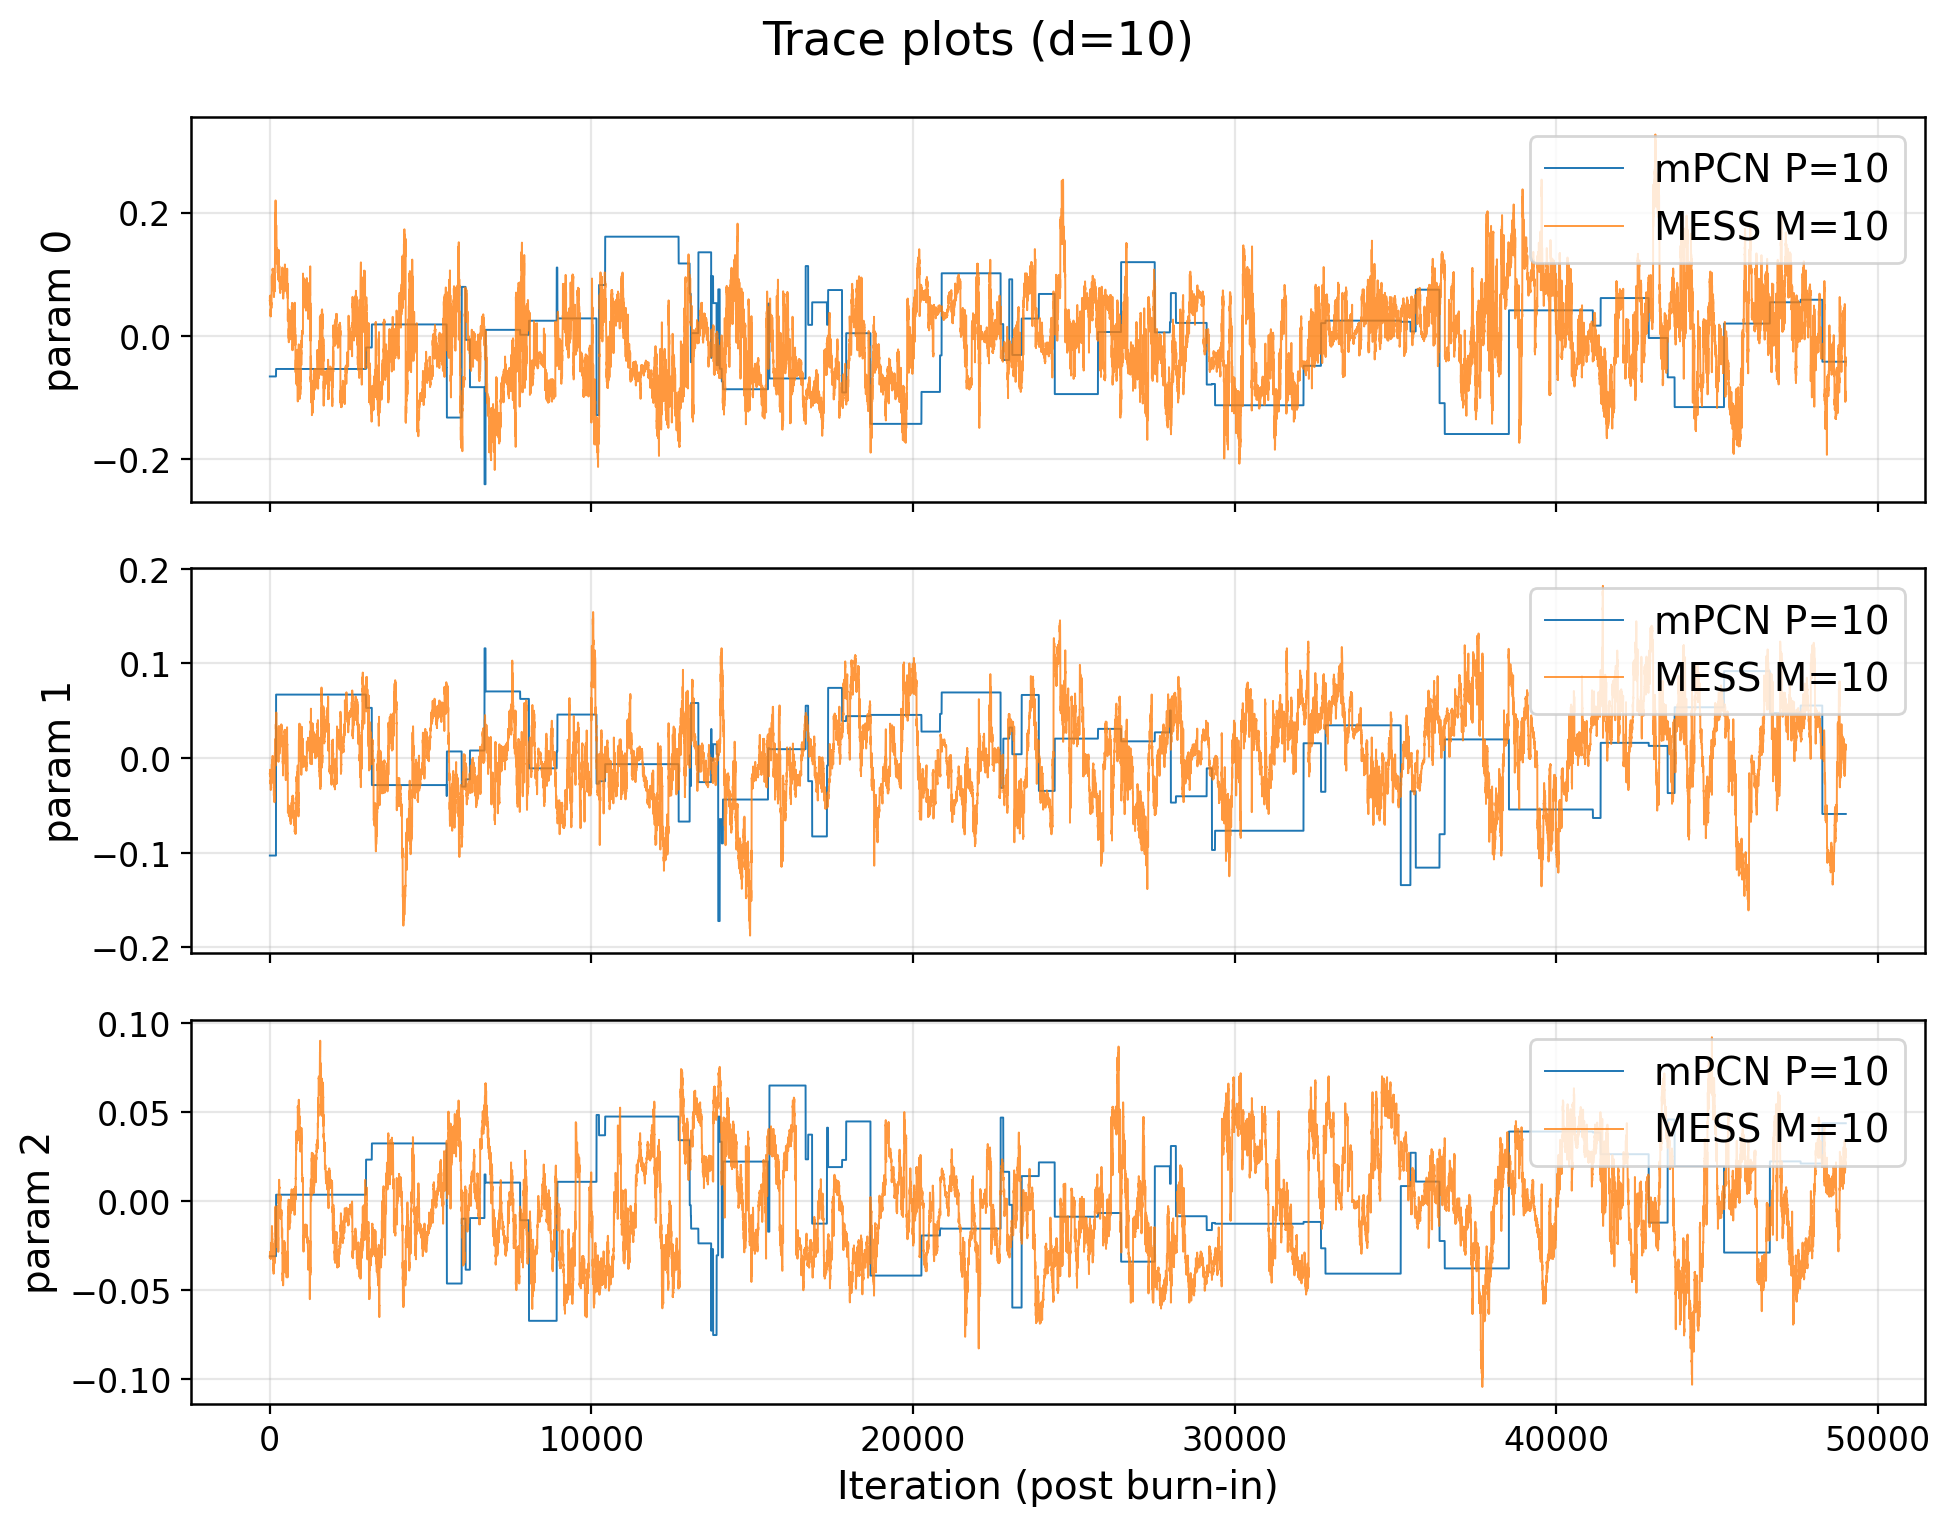

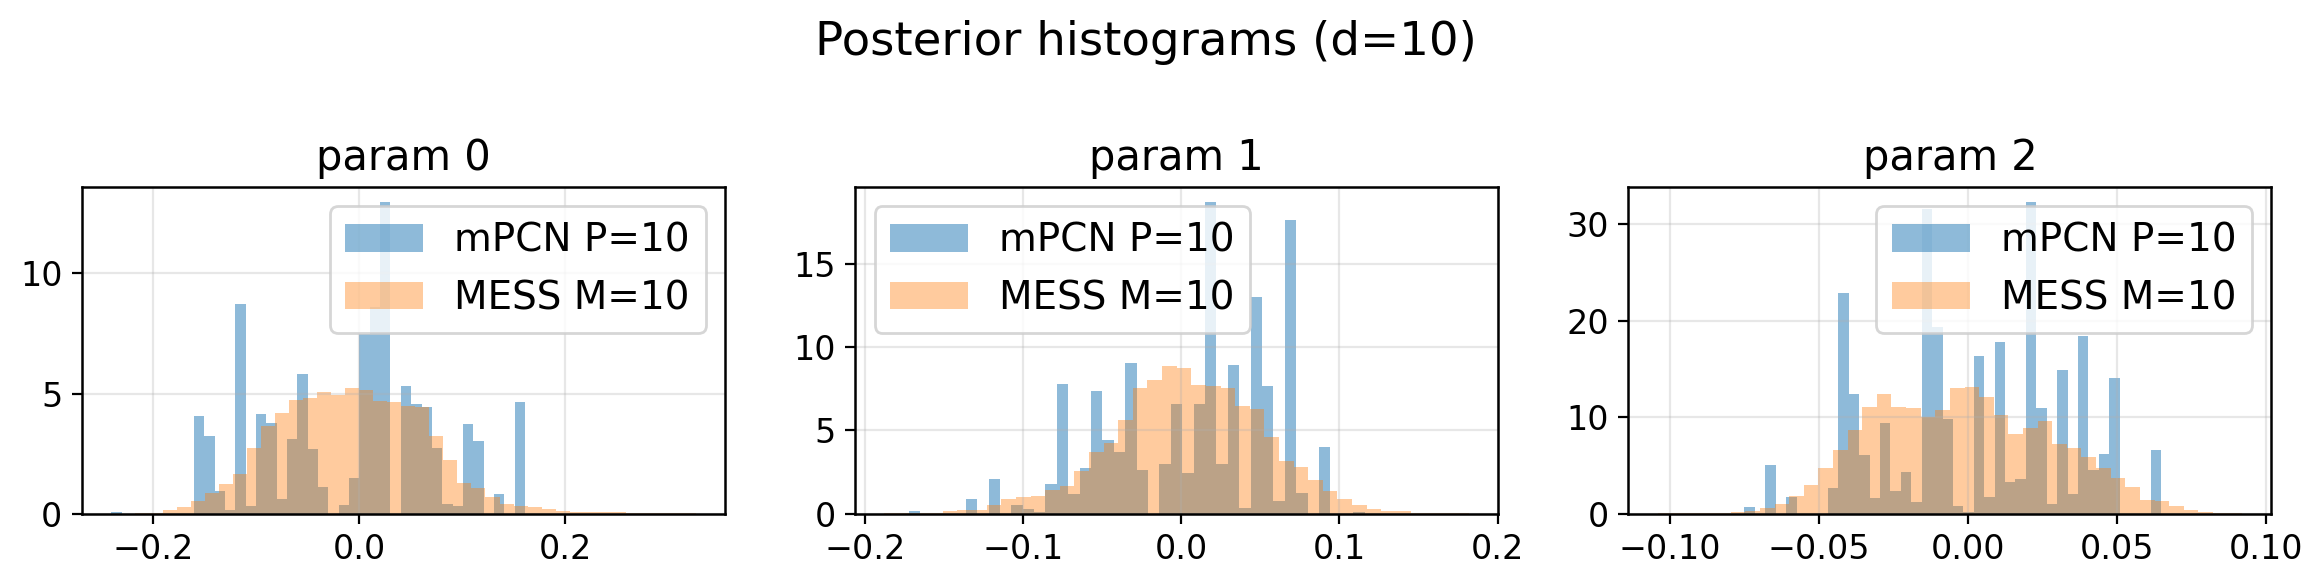

In [27]:
# Fixed-d diagnostics for selected parameters
apply_pub_style()
param_indices = [0, 1, 2]
param_indices = [idx for idx in param_indices if idx < problem_fixed.dim]

fig, axes = plt.subplots(len(param_indices), 1, figsize=(10, 2.6 * len(param_indices)), sharex=True)
if len(param_indices) == 1:
    axes = [axes]

for ax, p_idx in zip(axes, param_indices):
    for P in P_list:
        chain = fixed_results['mpcn'][P]['chain']
        ax.plot(chain[burn_in:, p_idx], linewidth=0.7, label=f'mPCN P={P}')
    if run_mess:
        for M in M_list:
            chain = fixed_results['mess'][M]['chain']
            ax.plot(chain[burn_in:, p_idx], linewidth=0.7, alpha=0.8, label=f'MESS M={M}')
    ax.set_ylabel(f'param {p_idx}')
    ax.grid(alpha=0.3)
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Iteration (post burn-in)')
fig.suptitle(f'Trace plots (d={d_fixed})')
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, len(param_indices), figsize=(4 * len(param_indices), 3))
if len(param_indices) == 1:
    axes = [axes]

for ax, p_idx in zip(axes, param_indices):
    for P in P_list:
        chain = fixed_results['mpcn'][P]['chain']
        ax.hist(chain[burn_in:, p_idx], bins=40, density=True, alpha=0.5, label=f'mPCN P={P}')
    if run_mess:
        for M in M_list:
            chain = fixed_results['mess'][M]['chain']
            ax.hist(chain[burn_in:, p_idx], bins=40, density=True, alpha=0.4, label=f'MESS M={M}')
    ax.set_title(f'param {p_idx}')
    ax.grid(alpha=0.3)
    ax.legend(loc='best')

fig.suptitle(f'Posterior histograms (d={d_fixed})')
fig.tight_layout()
plt.show()

In [13]:
# Shared-draws dimension sweep
sweep_results = {'mpcn': {}, 'mess': {}}

for d in d_list:
    problem_d, a_init_d, data_d = build_problem_for_dim(d)
    x0_d = a_init_d.copy()
    sweep_results['mpcn'][d] = {}
    for P in P_list:
        save_path = make_chain_path(
            estimations_dir,
            'sweep',
            'mpcn',
            d,
            seed_mcmc,
            rho=rho,
            P=P,
        )
        metrics_path = metrics_json_path(save_path)
        if save_path.exists():
            chain, metadata = _load_chain(save_path)
            runtime_sec = float(metadata.get('runtime_sec', np.nan)) if metadata else np.nan
            accept_rate = metadata.get('accept_rate', np.nan) if metadata else np.nan
            metrics = load_metrics_json(metrics_path)
            if metrics is None:
                metrics = summarize_chain_metrics(chain, runtime_sec, f'mPCN (d={d}, P={P}) [loaded]')
                save_metrics_json(metrics_path, metrics, accept_rate=accept_rate, runtime_sec=runtime_sec)
            print(f'Loaded mPCN chain from {save_path}')
        else:
            chain, runtime_sec, accept_rate = run_mpcn_chain(
                problem_d, x0_d, n_iters, rho, P, seed_mcmc
            )
            metrics = summarize_chain_metrics(chain, runtime_sec, f'mPCN (d={d}, P={P})')
            metadata = {
                'run_type': 'sweep',
                'sampler': 'mpcn',
                'd': d,
                'P': P,
                'rho': rho,
                'n_iters': n_iters,
                'burn_in': burn_in,
                'max_lag': max_lag,
                'seed_data': seed_data,
                'seed_mcmc': seed_mcmc,
                'shared_draws_seed': shared_draws_seed,
                'obs_config': obs_config,
                'obs_indices': data_d['obs_indices'].tolist(),
                'components': metrics['components'],
                'runtime_sec': runtime_sec,
                'accept_rate': accept_rate,
            }
            save_chain_npz(save_path, chain, metadata)
            save_metrics_json(metrics_path, metrics, accept_rate=accept_rate, runtime_sec=runtime_sec)
        sweep_results['mpcn'][d][P] = metrics
        metrics_rows.append(build_metrics_row('sweep', 'mpcn', d, P, None, rho, metrics, accept_rate))
    if run_mess:
        sweep_results['mess'][d] = {}
        for M in M_list:
            save_path = make_chain_path(
                estimations_dir,
                'sweep',
                'mess',
                d,
                seed_mcmc,
                M=M,
            )
            metrics_path = metrics_json_path(save_path)
            if save_path.exists():
                chain, metadata = _load_chain(save_path)
                runtime_sec = float(metadata.get('runtime_sec', np.nan)) if metadata else np.nan
                metrics = load_metrics_json(metrics_path)
                if metrics is None:
                    metrics = summarize_chain_metrics(chain, runtime_sec, f'MESS (d={d}, M={M}) [loaded]')
                    save_metrics_json(metrics_path, metrics, runtime_sec=runtime_sec)
                print(f'Loaded MESS chain from {save_path}')
            else:
                chain, runtime_sec = run_mess_chain(
                    problem_d, x0_d, n_iters, M, seed_mcmc
                )
                metrics = summarize_chain_metrics(chain, runtime_sec, f'MESS (d={d}, M={M})')
                metadata = {
                    'run_type': 'sweep',
                    'sampler': 'mess',
                    'd': d,
                    'M': M,
                    'n_iters': n_iters,
                    'burn_in': burn_in,
                    'max_lag': max_lag,
                    'seed_data': seed_data,
                    'seed_mcmc': seed_mcmc,
                    'shared_draws_seed': shared_draws_seed,
                    'obs_config': obs_config,
                    'obs_indices': data_d['obs_indices'].tolist(),
                    'components': metrics['components'],
                    'runtime_sec': runtime_sec,
                }
                save_chain_npz(save_path, chain, metadata)
                save_metrics_json(metrics_path, metrics, runtime_sec=runtime_sec)
            sweep_results['mess'][d][M] = metrics
            metrics_rows.append(build_metrics_row('sweep', 'mess', d, None, M, None, metrics))

if metrics_rows:
    write_metrics_csv(metrics_csv_path, metrics_rows, metrics_header, overwrite=True)
    print(f'Wrote metrics summary to {metrics_csv_path}')

print('Sweep complete.')


Estimating ESS for each parameter.
mPCN (d=10, P=10) runtime (min): 0.15
mPCN (d=10, P=10) mean ESS (components): 39.3
mPCN (d=10, P=10) mean MSJD (components): 8.458e-06
mPCN (d=10, P=10) ESS per minute: 260.24
Estimating ESS for each parameter.
MESS (d=10, M=10) runtime (min): 0.31
MESS (d=10, M=10) mean ESS (components): 106.9
MESS (d=10, M=10) mean MSJD (components): 6.688e-05
MESS (d=10, M=10) ESS per minute: 349.84
Estimating ESS for each parameter.
mPCN (d=20, P=10) runtime (min): 0.21
mPCN (d=20, P=10) mean ESS (components): 46.4
mPCN (d=20, P=10) mean MSJD (components): 1.062e-05
mPCN (d=20, P=10) ESS per minute: 220.05
Estimating ESS for each parameter.
MESS (d=20, M=10) runtime (min): 0.36
MESS (d=20, M=10) mean ESS (components): 131.5
MESS (d=20, M=10) mean MSJD (components): 7.713e-05
MESS (d=20, M=10) ESS per minute: 369.20


KeyboardInterrupt: 

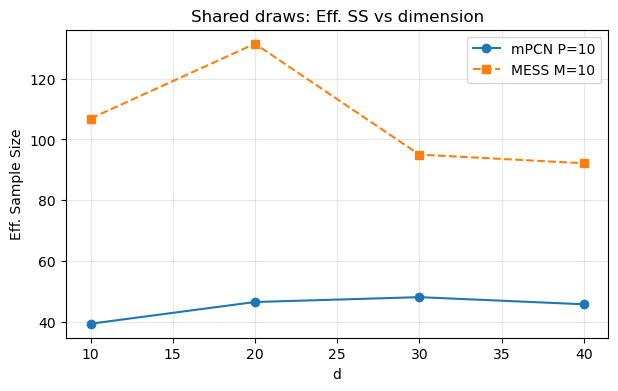

In [ ]:
# Compare ESS vs dimension
apply_pub_style()
fig, ax = plt.subplots(figsize=(7, 4))
for P in P_list:
    ess_vals = [sweep_results['mpcn'][d][P]['ess_mean'] for d in d_list]
    ax.plot(d_list, ess_vals, marker='o', label=f'mPCN P={P}')

if run_mess:
    for M in M_list:
        ess_vals = [sweep_results['mess'][d][M]['ess_mean'] for d in d_list]
        ax.plot(d_list, ess_vals, marker='s', linestyle='--', label=f'MESS M={M}')

ax.set_xlabel('d')
ax.set_ylabel('Eff. Sample Size')
ax.set_title('Shared draws: Eff. SS vs dimension')
ax.grid(alpha=0.3)
ax.legend(loc='best')
plt.show()

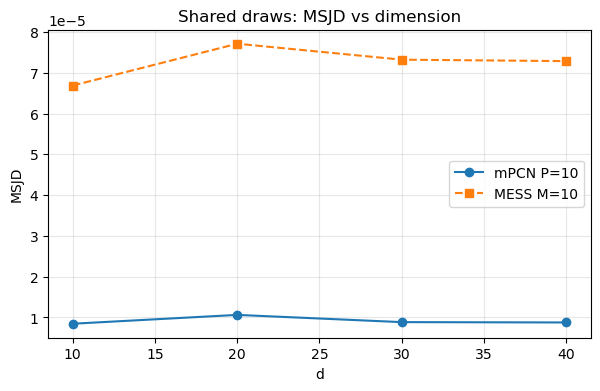

In [ ]:
# Compare MSJD vs dimension
apply_pub_style()
fig, ax = plt.subplots(figsize=(7, 4))
for P in P_list:
    ess_vals = [sweep_results['mpcn'][d][P]['msjd_mean'] for d in d_list]
    ax.plot(d_list, ess_vals, marker='o', label=f'mPCN P={P}')

if run_mess:
    for M in M_list:
        ess_vals = [sweep_results['mess'][d][M]['msjd_mean'] for d in d_list]
        ax.plot(d_list, ess_vals, marker='s', linestyle='--', label=f'MESS M={M}')

ax.set_xlabel('d')
ax.set_ylabel('MSJD')
ax.set_title('Shared draws: MSJD vs dimension')
ax.grid(alpha=0.3)
ax.legend(loc='best')
plt.show()

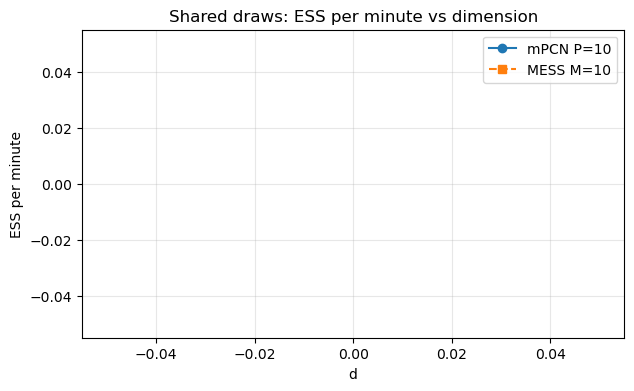

In [ ]:
# Compare ESS per minute vs dimension
apply_pub_style()
fig, ax = plt.subplots(figsize=(7, 4))
for P in P_list:
    ess_vals = [sweep_results['mpcn'][d][P]['ess_per_min'] for d in d_list]
    ax.plot(d_list, ess_vals, marker='o', label=f'mPCN P={P}')

if run_mess:
    for M in M_list:
        ess_vals = [sweep_results['mess'][d][M]['ess_per_min'] for d in d_list]
        ax.plot(d_list, ess_vals, marker='s', linestyle='--', label=f'MESS M={M}')

ax.set_xlabel('d')
ax.set_ylabel('ESS per minute')
ax.set_title('Shared draws: ESS per minute vs dimension')
ax.grid(alpha=0.3)
ax.legend(loc='best')
plt.show()